# 04 · Evaluate the CL latents

Is the learned 2D representation informative about A, B and insensitive to C?
Reads `outputs/<run>/cl/` and `data/<run>/{pk,latents}/`. Writes PNGs and `invariance.json` to
`outputs/<run>/cl/`. Next: `05_train_SBI_Pk.ipynb`.

In [1]:
import config as cfg
from clmini import data, cl, sbi_tools, metrics, plots
print(f"run = {cfg.RUN_NAME} | data -> {cfg.DATA_DIR.relative_to(cfg.ROOT)} | outputs -> {cfg.OUT_DIR.relative_to(cfg.ROOT)}")

run = full | data -> data/full | outputs -> outputs/full


PosixPath('outputs/full/cl/loss.png')

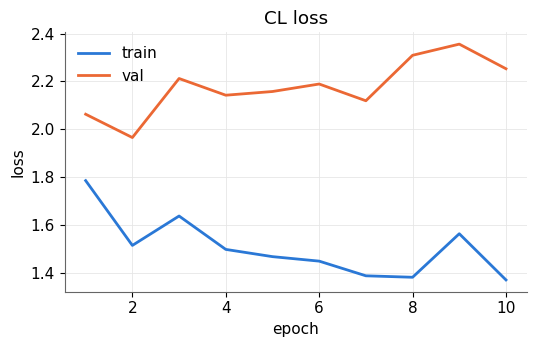

In [2]:
fig = plots.loss_history(cl.load_history(cfg)); metrics.save_fig(cfg, fig, "cl/loss")

## Clusters of views
All views of one cosmology (v1: o, v2: x) should collapse onto one point.

PosixPath('outputs/full/cl/latent_clusters.png')

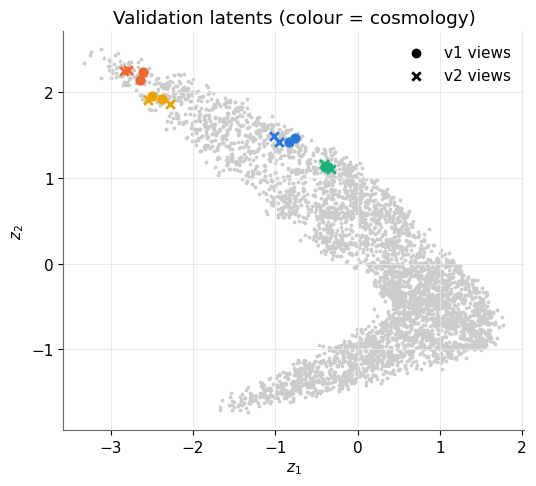

In [3]:
fig = plots.latent_clusters(cfg); metrics.save_fig(cfg, fig, "cl/latent_clusters")

## Latent plane coloured by each parameter (C-grid test set)

PosixPath('outputs/full/cl/latent_plane_by_param.png')

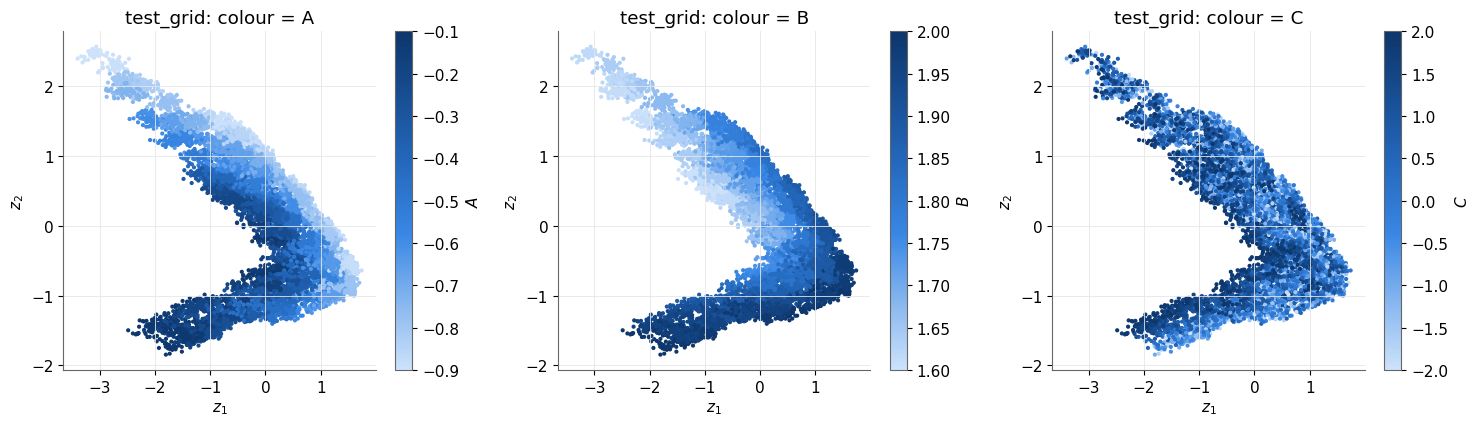

In [4]:
fig = plots.latent_plane_by_param(cfg); metrics.save_fig(cfg, fig, "cl/latent_plane_by_param")

PosixPath('outputs/full/cl/latents_vs_params.png')

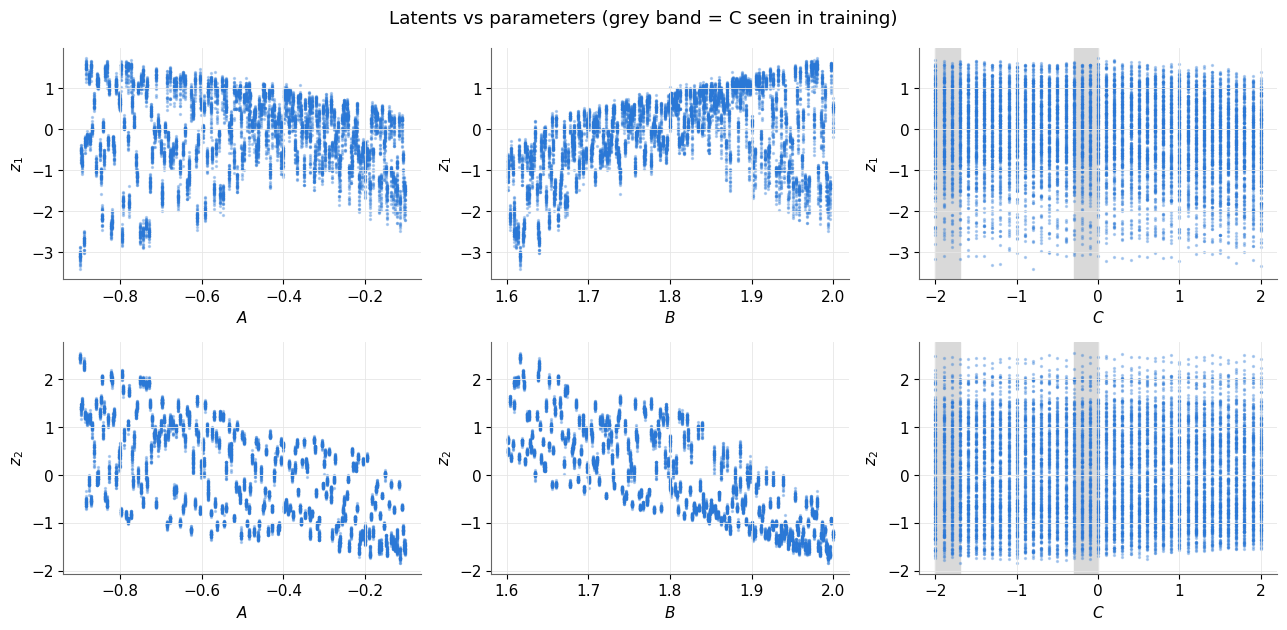

In [5]:
fig = plots.latents_vs_params(cfg); metrics.save_fig(cfg, fig, "cl/latents_vs_params")

## Invariance metric
`sqrt(E[within-cosmology variance] / Var[between-cosmology means])`, summed over dimensions: 0 means perfectly invariant to C (and noise). The input spectra are shown as a baseline.

In [6]:
inv = metrics.cl_invariance_metrics(cfg)
metrics.save_json(cfg, inv, "cl/invariance.json")
import pandas as pd; pd.DataFrame(inv).round(3)

,pk,latents
val_v1_v2,0.549,0.058
test_grid_training_C,0.562,0.068
test_grid_all_C,0.748,0.143


PosixPath('outputs/full/cl/invariance_vs_C.png')

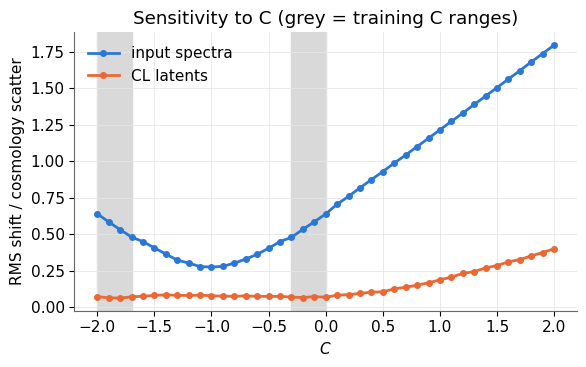

In [7]:
fig = plots.invariance_vs_c(cfg); metrics.save_fig(cfg, fig, "cl/invariance_vs_C")